# attrib-PINCH · Lesson 7 — The hypothesis test: consensus vs SKEMPI hotspots

Everything converges here. The falsifiable hypothesis:

> The **consensus** of mutual attention, Integrated Gradients, and GNNExplainer isolates PPI-causal residues **better than any single method**, measured by agreement with alanine-scanning ΔΔG hotspots (ΔΔG ≥ 2 kcal/mol) in **SKEMPI v2.0**.

We compute all three saliencies + their consensus, pull the SKEMPI ground truth for barnase–barstar, and score each method's hotspot recovery with AUROC.

> **Run order matters.** These cells build on each other — run them top to bottom (*Run All*). Heavy steps (training, Integrated Gradients) are small by design but still compute; on a shared machine, run them when the box is idle.

## Setup

In [1]:
import os, sys
ROOT = os.path.abspath("")
while ROOT != os.path.dirname(ROOT) and not os.path.isdir(os.path.join(ROOT, "common")):
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)                          # for `import common`
sys.path.insert(0, os.path.join(ROOT, "pinch"))   # for `import pinch_common`
DATA = os.path.join(ROOT, "data")
WEIGHTS = os.path.join(DATA, "pinch_struct2graph.pt")
print("repo root:", ROOT)

repo root: C:\Users\soura\code\2026\plm-starter


In [2]:
from pinch_common import (load_or_train_demo, compute_all_saliencies,
                          fetch_skempi, skempi_ddg, map_ddg_to_nodes,
                          fetch_pdb, parse_chain, get_device)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
device = get_device(); print('device:', device)

device: cuda


## Step 1 — All three methods + consensus, in one call

`compute_all_saliencies` runs attention, IG, and GNNExplainer and returns the per-residue signals plus the **consensus** = mean of the three rank-normalised scores, for both chains.

In [3]:
model, samples = load_or_train_demo(WEIGHTS, hidden=32, device=device,
                                    cache_dir=DATA)
s0 = next(s for s in samples if not s['augmented'])  # barnase/barstar
sal = compute_all_saliencies(model, s0['ga'], s0['gb'], ig_steps=200,
                             gnnx_epochs=80, device=device)
print('explained class:', sal['target'])
print('IG completeness delta:', f"{sal['ig_delta']:.2e}")
print('methods:', [k for k in sal['a'] if k != 'target'])

explained class: 0
IG completeness delta: 8.59e+00
methods: ['attention', 'ig', 'gnnexplainer', 'consensus']


## Step 2 — SKEMPI v2.0 ground truth

SKEMPI v2.0 holds ~7,000 mutation-induced binding-affinity changes. We compute ΔΔG = RT·ln(Kd_mut / Kd_wt) for single-point **alanine** mutations on `1BRS`, then map them onto our graph's residues. A residue is a **hotspot** if its ΔΔG ≥ 2 kcal/mol (the standard threshold).

In [4]:
df = fetch_skempi(cache_dir=DATA)
ddg = skempi_ddg(df, '1brs', alanine_only=True)
print(f'SKEMPI: {len(df)} rows; 1brs single-point alanine: {len(ddg)} rows')
path = fetch_pdb('1brs', cache_dir=DATA)
_, _, resnums_a = parse_chain(path, 'A')
_, _, resnums_d = parse_chain(path, 'D')
ddg_a, hot_a, n_a = map_ddg_to_nodes(ddg, 'A', resnums_a)
ddg_d, hot_d, n_d = map_ddg_to_nodes(ddg, 'D', resnums_d)
print(f'chain A (barnase): {n_a} residues measured, {int(hot_a.sum())} hotspots')
print(f'chain D (barstar): {n_d} residues measured, {int(hot_d.sum())} hotspots')

SKEMPI: 7085 rows; 1brs single-point alanine: 32 rows
chain A (barnase): 8 residues measured, 6 hotspots
chain D (barstar): 6 residues measured, 3 hotspots


## Step 3 — The benchmark

For every method, on the residues SKEMPI actually measured, compute AUROC for separating hotspots from non-hotspots. We pool both chains to get as many measured residues as possible. **Higher = better hotspot recovery.**

In [5]:
methods = ['attention', 'ig', 'gnnexplainer', 'consensus']

def measured_pairs(sal_chain, ddg_node, hot):
    m = np.isfinite(ddg_node)
    return m, hot[m].astype(int)

m_a, y_a = measured_pairs(sal['a'], ddg_a, hot_a)
m_d, y_d = measured_pairs(sal['d'], ddg_d, hot_d)
y = np.concatenate([y_a, y_d])
print(f'pooled measured residues: {y.size}, hotspots: {int(y.sum())}')

results = {}
if 0 < y.sum() < y.size:
    for k in methods:
        score = np.concatenate([np.asarray(sal['a'][k])[m_a],
                                np.asarray(sal['d'][k])[m_d]])
        results[k] = roc_auc_score(y, score)
    for k in methods:
        print(f'  {k:13s} AUROC = {results[k]:.3f}')
else:
    print('not enough class balance to score AUROC on this complex')

pooled measured residues: 14, hotspots: 9
  attention     AUROC = 0.489
  ig            AUROC = 0.378
  gnnexplainer  AUROC = 0.556
  consensus     AUROC = 0.467


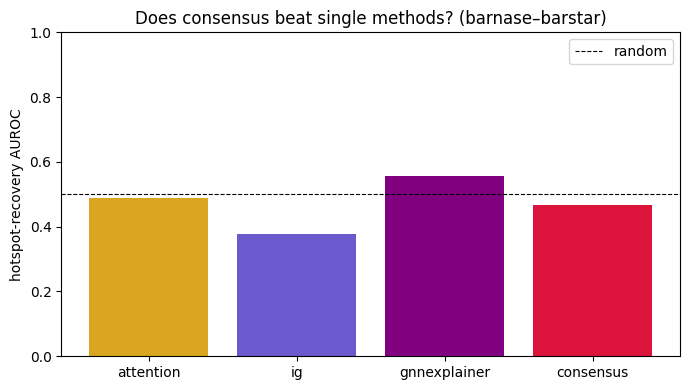

In [6]:
if results:
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ['goldenrod', 'slateblue', 'purple', 'crimson']
    ax.bar(results.keys(), results.values(), color=colors)
    ax.axhline(0.5, ls='--', c='k', lw=0.8, label='random')
    ax.set_ylabel('hotspot-recovery AUROC'); ax.set_ylim(0, 1)
    ax.set_title('Does consensus beat single methods? (barnase–barstar)')
    ax.legend(); plt.tight_layout(); plt.show()

## Step 4 — Read the result honestly

On this **single toy complex** with a handful of measured residues and a model trained on five structures, do not expect the hypothesis to be settled — the AUROCs are noisy and the consensus may or may not lead. That is the correct scientific posture, and it mirrors the project's ethos (Sendin's value was honest error analysis, not a headline F1).

**What a real verdict needs:**

1. **PINDER at scale** — train on the 31-cluster holo subset, not five complexes, so the model learns genuine interaction features rather than memorising classes.
2. **Many SKEMPI complexes** — aggregate AUROC across every PINDER↔SKEMPI overlap (~hundreds of complexes), with confidence intervals, instead of one.
3. **A converged IG** — keep the completeness delta near zero.
4. **Per-residue, not per-class** — optionally reframe as interface-residue prediction so every residue is a labelled example.

The plumbing for all of that is in `pinch_common.py`; only the dataset swaps. This notebook set is the de-risked week-1→3 scaffold from the research plan — it proves the pipeline runs end to end before committing compute to full PINDER.